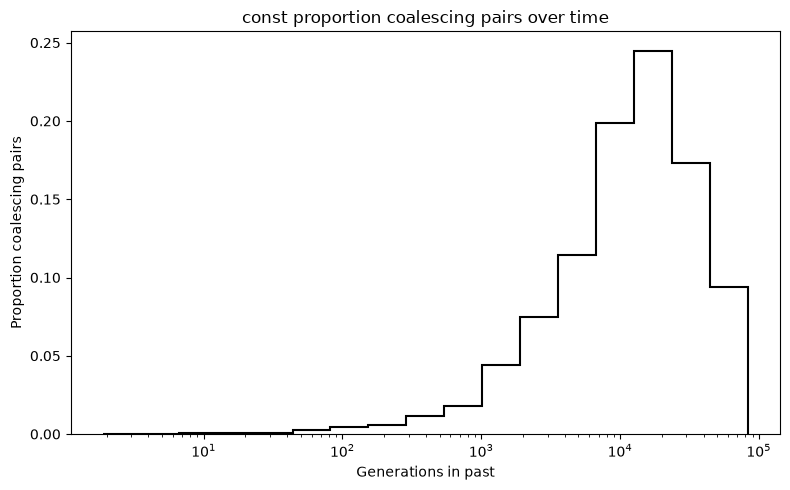

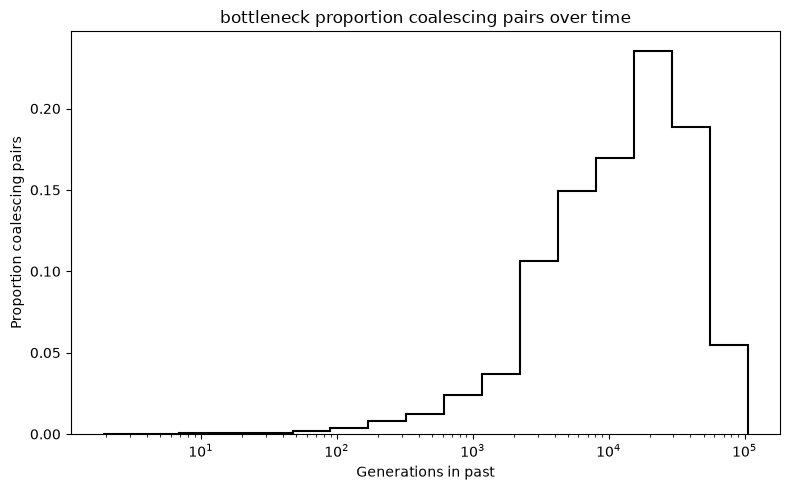

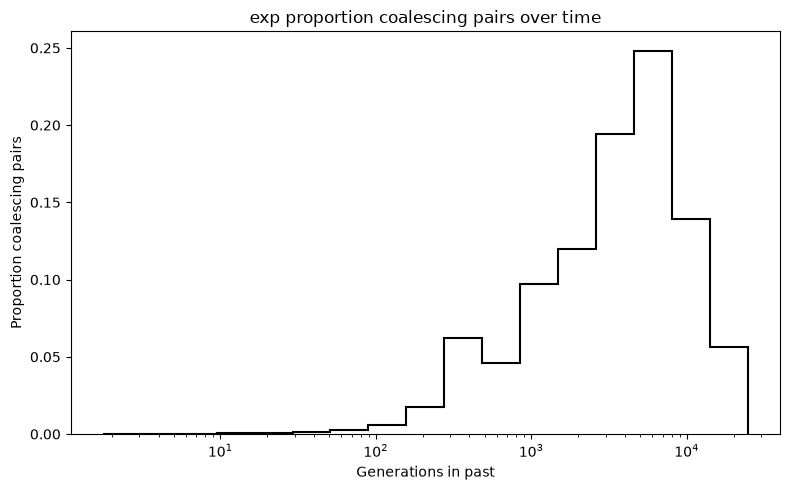

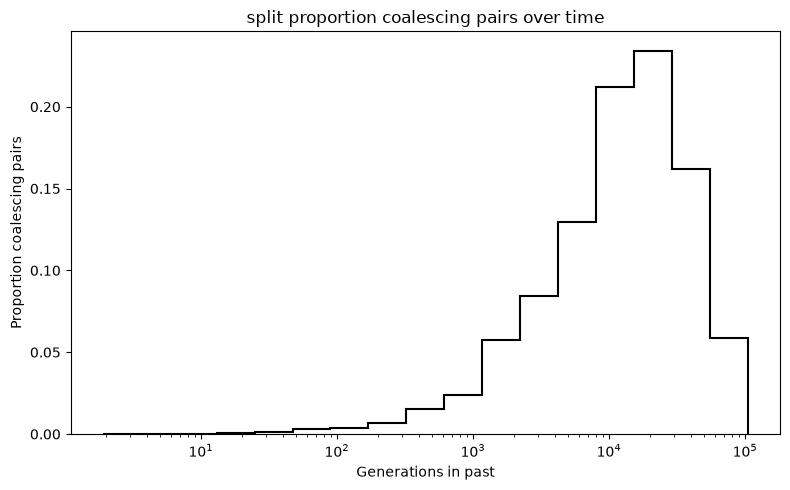

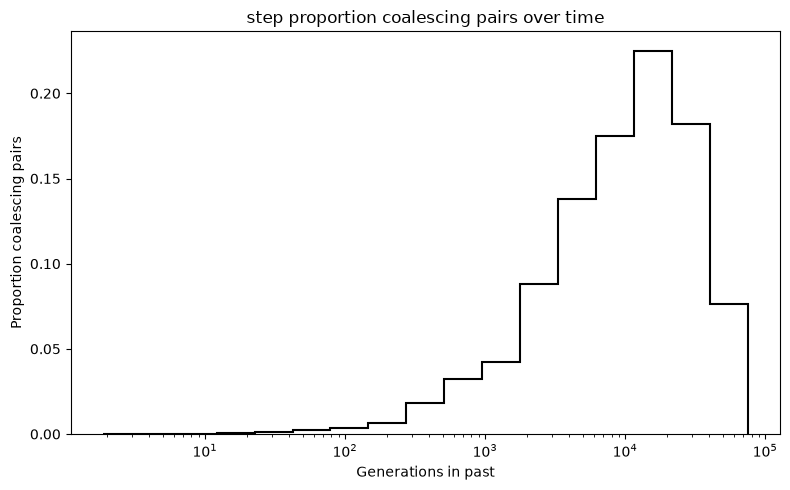

In [8]:

import msprime
import numpy as np
import matplotlib.pyplot as plt

# Creating demographies
#1) Single pop: Constant population size
demoConst = msprime.Demography()
demoConst.add_population (name='popA', initial_size=10000)

#2) Single pop: Bottleneck
demoBottleneck = msprime.Demography()
demoBottleneck.add_population (name='popA', initial_size=5000)
demoBottleneck.add_population_parameters_change (population='popA', time=5, initial_size=10000)


#3) Single pop: Recent exp. growth
demoExp = msprime.Demography()
demoExp.add_population (name='popA', initial_size=10000, growth_rate = np.log(4)/250)
demoExp.add_population_parameters_change (population='popA', time=250, growth_rate = 0)


#4) Two pops: Pop. split
demoSplit= msprime.Demography()
demoSplit.add_population (name='popA', initial_size=5000)
demoSplit.add_population (name='popB', initial_size=5000)
demoSplit.add_population (name='popAB', initial_size=10000)
demoSplit.add_population_split (time=250, derived=["popA", "popB"], ancestral="popAB")

#5) Stepping stone
def isValidDeme(deme, dim):
    """
    Checks whether the given deme is within the boundaries.
    """
    (n, m) = dim
    (i, j) = deme
    isValid = True
    isValid &= ((i >= 0) and (i < n))
    isValid &= ((j >= 0) and (j < m))
    return isValid


# %%
def stepping_stone2d (meta_size, migRate, treeSeq = None):
    """
    sets up a demographic model representing a 2D stepping-stone model
    """
    assert len(meta_size.shape) == 2
    n, m = meta_size.shape

    # just double check
    if ((n == 1) and (m == 1)):
        assert (migRate is None)
    else:
        assert (migRate is not None)
    # fill it in an order where column index j increases fastest until m
    idxToDeme = {}
    # but it starts at 1 because of slim
    currIdx = 1
    for i in range(n):
        for j in range (m):
            idxToDeme[currIdx] = (i,j)
            currIdx += 1

    # the inverse map
    demeToIdx = {}
    for (thisIdx, thisPair) in idxToDeme.items():
        # make sure it matches what we used in SLiM
        assert (thisPair[0]*m + thisPair[1] + 1 == thisIdx)
        demeToIdx[thisPair] = thisIdx

    # we need one bogus population to emulate slim
    if (treeSeq is None):
        demography = msprime.Demography.isolated_model (np.concatenate (([1], meta_size.reshape(n*m))))
        # AS LONG AS THE SECOND INDEX INCREASES FASTER, THE ORDERING OF THE SIZES IS CORRECT
    else:
        # need to initialize from treeSeq, so the populations match
        demography = msprime.Demography.from_tree_sequence(treeSeq)
        for pop in demography.populations:
            # must set their effective population sizes
            if (pop.id < 1):
                # this one is bogus (who knows why SLiM puts it here)
                pop.initial_size = 1
            else:
                # real population
                thisPair = idxToDeme[pop.id]
                pop.initial_size = meta_size[thisPair[0],thisPair[1]]

    # still need to put in migration rates
    migMatrix = demography.migration_matrix
    # iterate over source demes
    # for srcIdx in range(M.shape[0]):
    # this is all due to SLiM, because there is one empty pop in the beginning
    for srcIdx in range(1,migMatrix.shape[0]):
        srcDeme = idxToDeme[srcIdx]
        (srcI, srcJ) = srcDeme
        # don't rename
        # demography.populations[srcIdx].name = f"pop_{srcI}_{srcJ}"
        # print(srcDeme)

        # where can we go from here
        dstDemes = [
            (srcI + 1, srcJ),
            (srcI - 1, srcJ),
            (srcI, srcJ + 1),
            (srcI, srcJ - 1),
        ]
        for dstDeme in dstDemes:
            if isValidDeme(dstDeme, (n,m)):
                # print(f"--> {dstDeme}")
                assert (migRate is not None)
                migMatrix[demeToIdx[srcDeme], demeToIdx[dstDeme]] = migRate
            # else:
                # print(f"-x> {(dstDeme[0] % n, dstDeme[1] % m)}")

    return (demography, idxToDeme, demeToIdx)
meta_size = np.ones((4,4))*500
(demoStep, idxToDeme, demeToIdx) = stepping_stone2d(meta_size,0.05)

deme_list = [demoConst, demoBottleneck, demoExp, demoSplit, demoStep]
demo_names = ["const", "bottleneck", "exp", "split", "step"]
L = 2e6

for i in range(2):
    import os
    os.makedirs(f'my-singer-run/example_data/diploid_sim/{demo_names[i]}', exist_ok=True)

    if i == 3:
        samples = {"popA": 50, "popB": 50}
    elif i == 4:
        samples = {f"pop_{num}": 5
                   for num in range(1,17)}
    else:
        samples = {"popA": 100}

    simple_demo = msprime.sim_ancestry(
        demography=deme_list[i],
        samples=samples,
        sequence_length=L,
        recombination_rate=1.25e-8,
        random_seed=121212,
    )
    mutated = msprime.sim_mutations(simple_demo, rate=1.25e-8, random_seed=523802156)
    mutated.write_vcf(open(f'example/diploid_sim/{demo_names[i]}/{demo_names[i]}.vcf', 'w'))
    
    #now make graph of probability of pairwise coalescence per time chunk (exponential x axis, matching SINGER output)
    fig, ax = plt.subplots(figsize=(8, 5))
    time_intervals = np.logspace(0, np.log10(mutated.max_time), 20)
    #time_intervals = np.concatenate(([0], time_intervals, [np.inf]))
    #this functions creates a vector of the number of coalescing pairs in each interval
    counts = mutated.pair_coalescence_counts(time_windows=time_intervals)
    #normalize 
    proportions = counts/counts.sum() 
    #ignore 1st and last interval to match singer chart
    ax.stairs(proportions[1:-1], time_intervals[1:-1], color="black", linewidth=1.5)
    ax.set_xscale("log")
    ax.set_xlabel("Generations in past")
    ax.set_ylabel("Proportion coalescing pairs")
    plt.title(f"{demo_names[i]} proportion coalescing pairs over time")
    plt.tight_layout()
    plt.show()


In [27]:
i = 4
import os
outdir = f'my-singer-run/example_data/diploid_sim/{demo_names[i]}'
os.makedirs(f'{outdir}', exist_ok=True)
L = 2e6
        
if i == 3:
    samples = {"popA": 50, "popB": 50}
elif i == 4:
    samples = {f"pop_{num}": 5
    for num in range(1,17)}
else:
   samples = {"popA": 100}
        
simple_demo = msprime.sim_ancestry(
    demography=deme_list[i],
    samples=samples,
    sequence_length=L,
    recombination_rate=1.25e-8,
    random_seed=121212,
    )
mutated = msprime.sim_mutations(simple_demo, rate=1.25e-8, random_seed=523802156)



In [15]:
demo_names[2]

'exp'

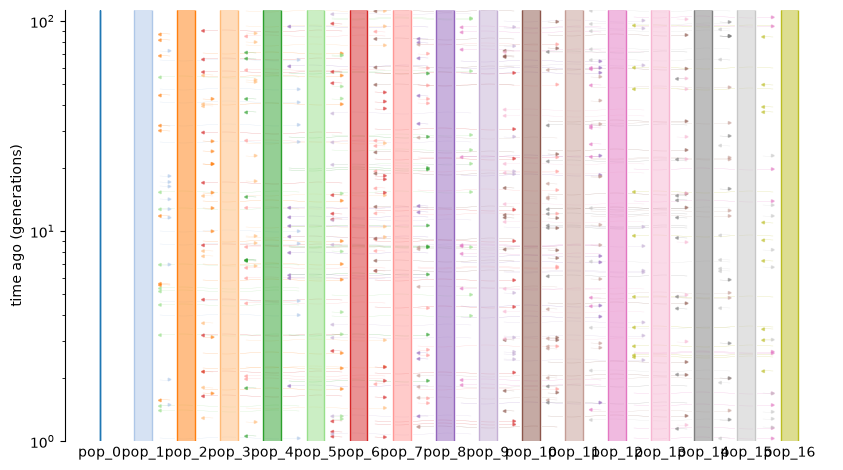

In [31]:
import demesdraw
graph = demoStep.to_demes()

# 3. Visualize using demesdraw
demesdraw.tubes(graph, log_time=True)
plt.show()

In [30]:
pip install demesdraw

Note: you may need to restart the kernel to use updated packages.
